<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/17_power_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer


In [7]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/concrete_data.csv")

In [8]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [9]:
df.shape

(1030, 9)

In [11]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [12]:
df.head(1)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99


In [15]:
X=df.iloc[:,0:8]
y=df.iloc[:,-1]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [21]:
r2_score(y_pred,y_test)

0.4231704797890976

In [24]:
np.mean(cross_val_score(lr,X,y,scoring="r2")).round(2)

np.float64(0.46)

In [25]:
X_train.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age'],
      dtype='object')

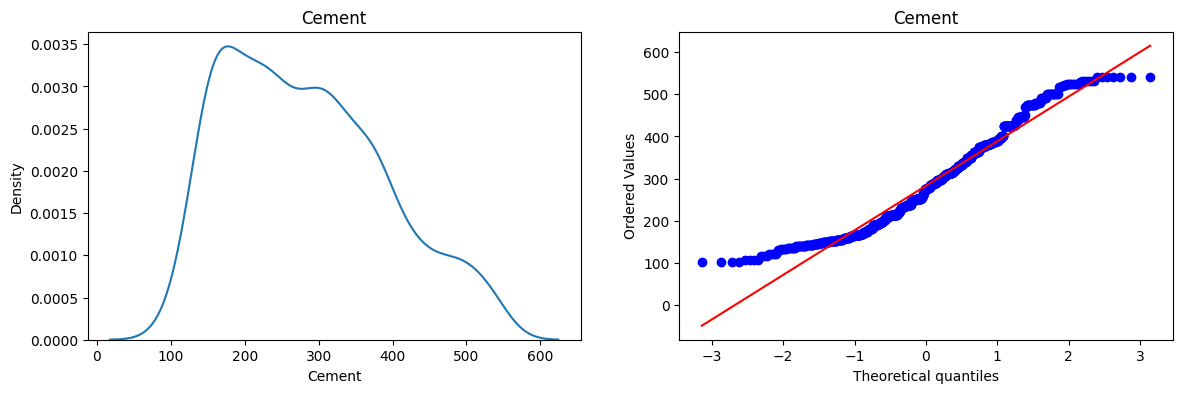

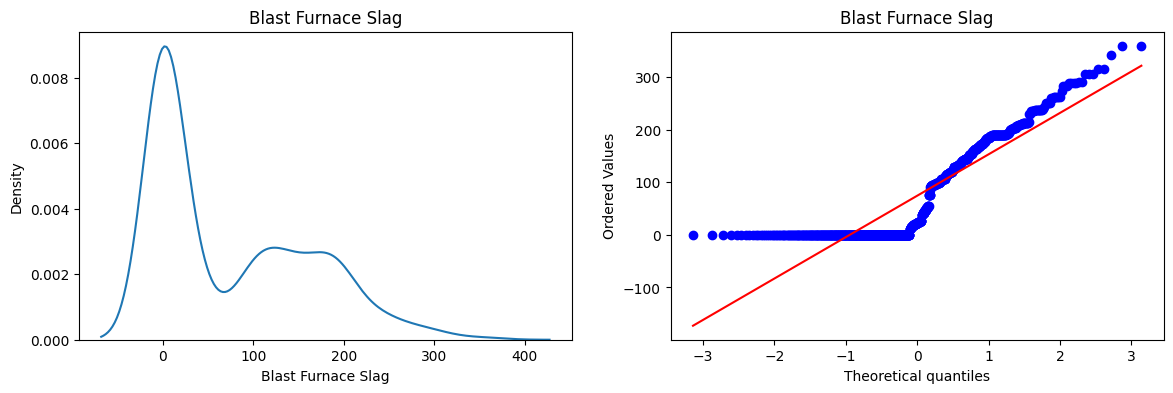

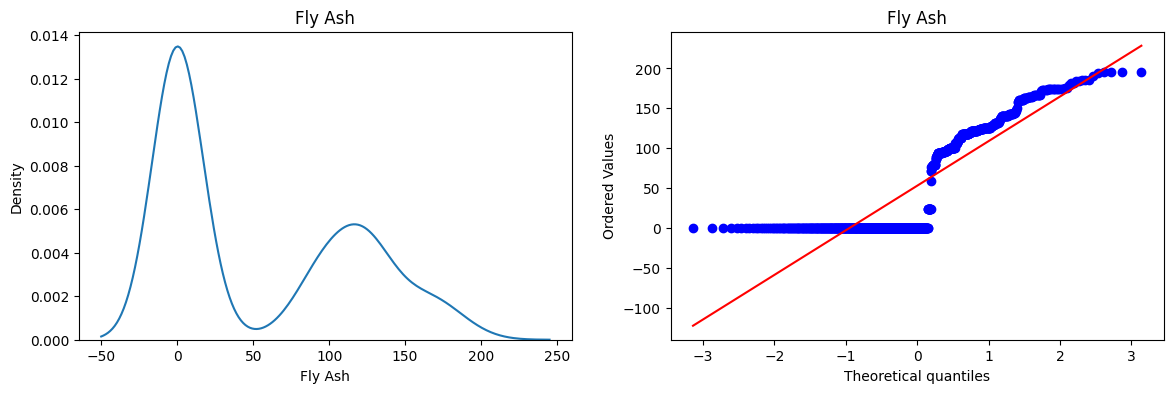

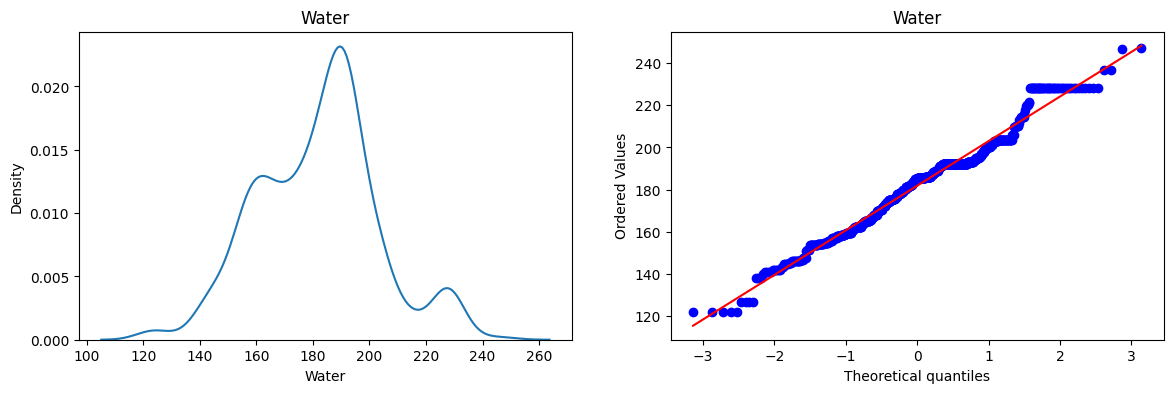

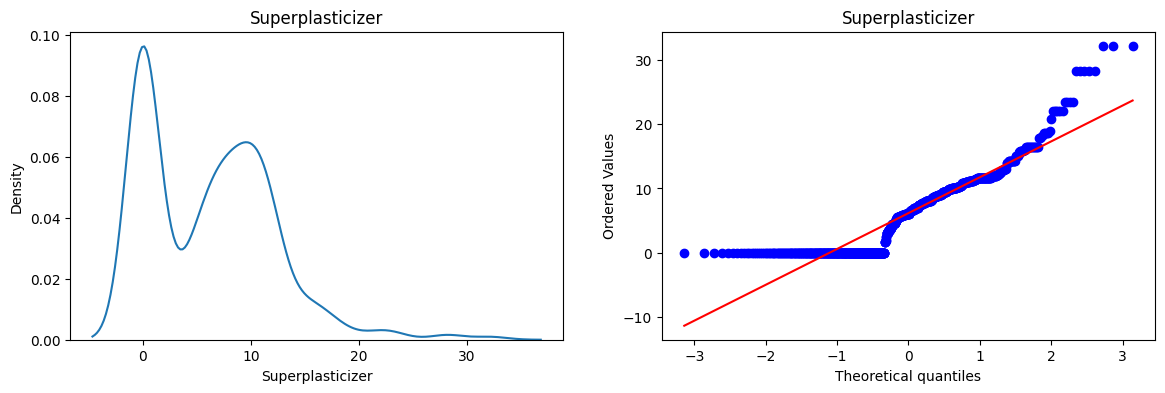

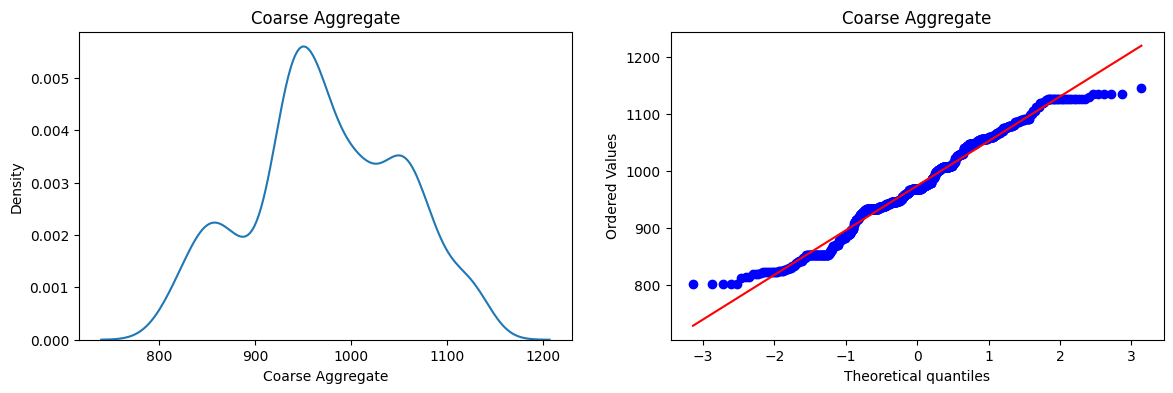

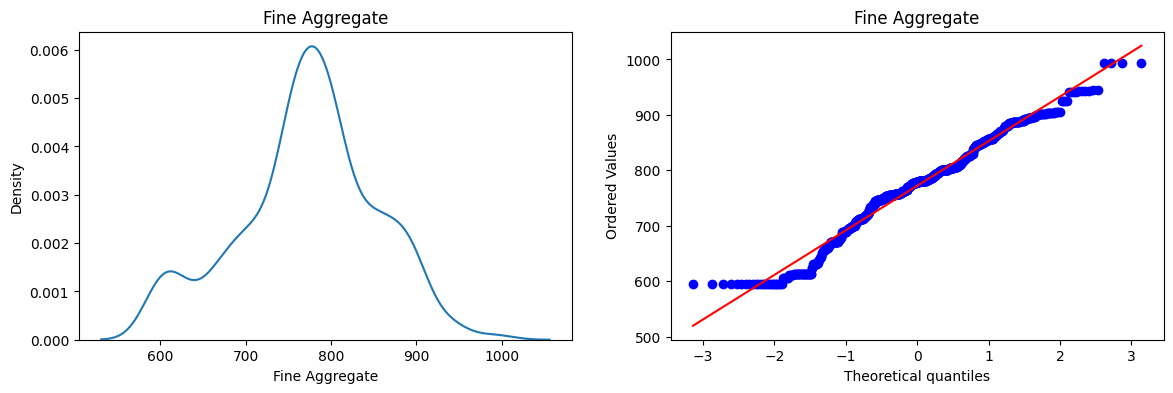

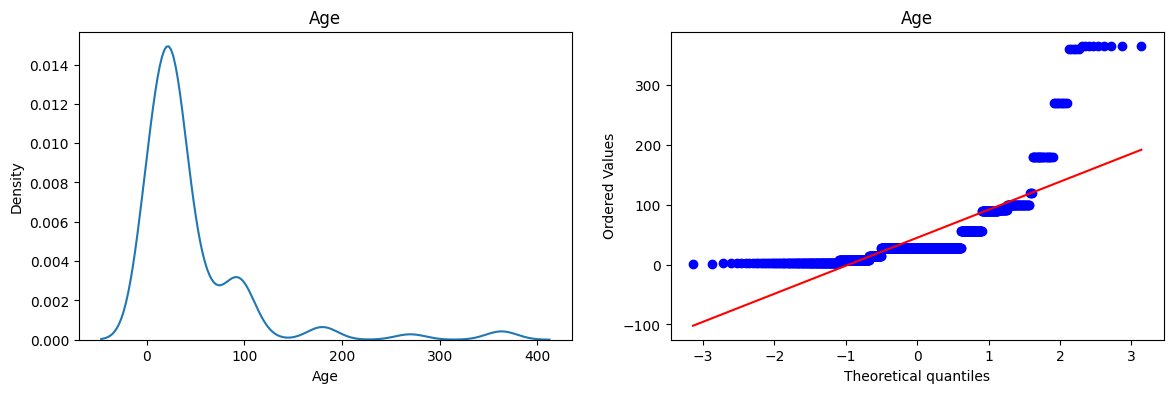

In [32]:
from scipy.stats import probplot

for col in X_train.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.kdeplot(X_train[col])
  plt.title(col)

  plt.subplot(122)
  probplot(X_train[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()

In [36]:
# Applying Box-Cox Transform
pt = PowerTransformer(method='box-cox')
X_trans_trf1=pt.fit_transform(X_train+0.0001)
X_test_trf1=pt.transform(X_test+0.0001)

In [61]:
# Applying linear regression on transformed data

lr = LinearRegression()
lr.fit(X_trans_trf1,y_train)
y_pred2 = lr.predict(X_test_trf1)
r2_score(y_test,y_pred2)

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt.lambdas_})

,cols,Yeo_Johnson_lambdas
0,Cement,0.172271
1,Blast Furnace Slag,0.022924
2,Fly Ash,-0.028797
3,Water,0.809568
4,Superplasticizer,0.087911
5,Coarse Aggregate,1.129167
6,Fine Aggregate,1.829625
7,Age,0.048975


In [39]:
X_transformed = pt.fit_transform(X+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6658537935432477)

In [45]:
X_train_transformed = pd.DataFrame(X_trans_trf1,columns=X_train.columns)

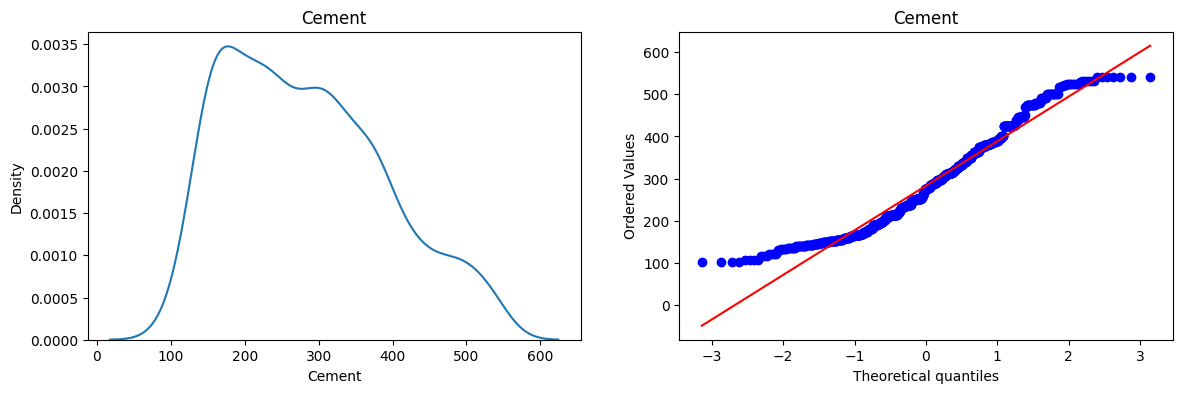

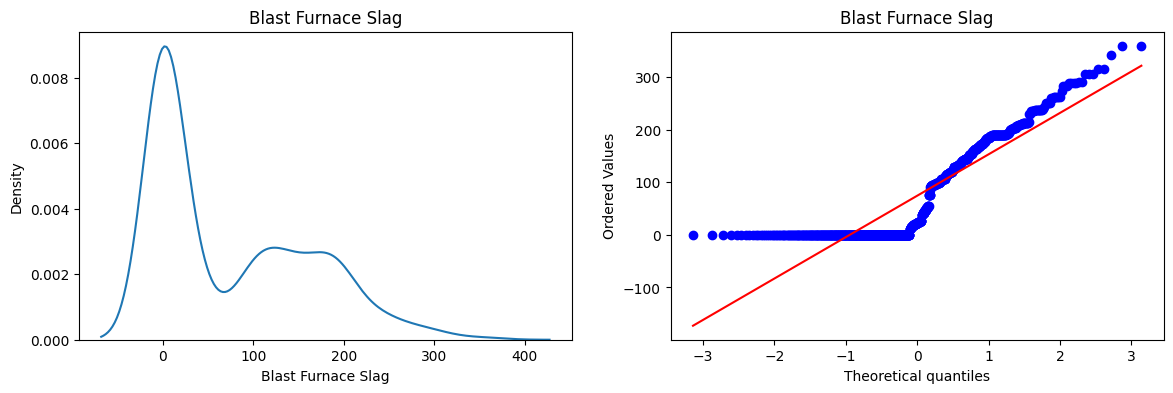

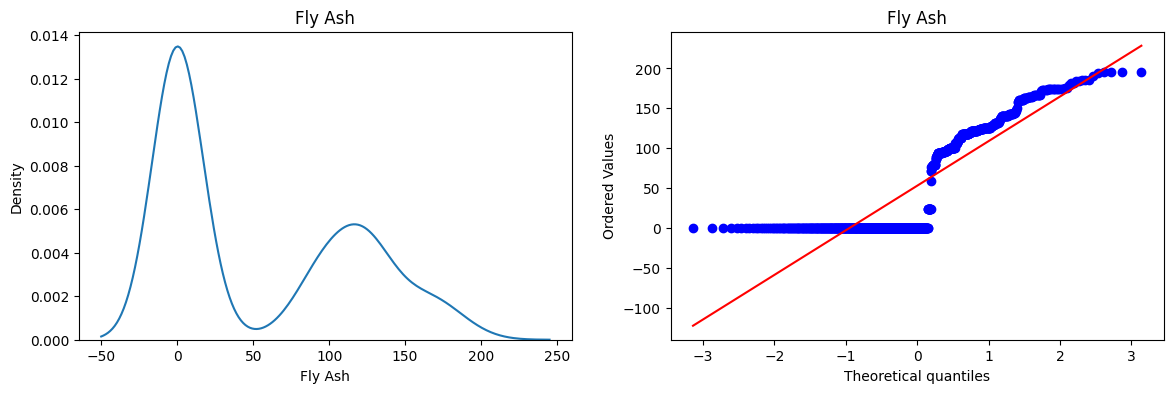

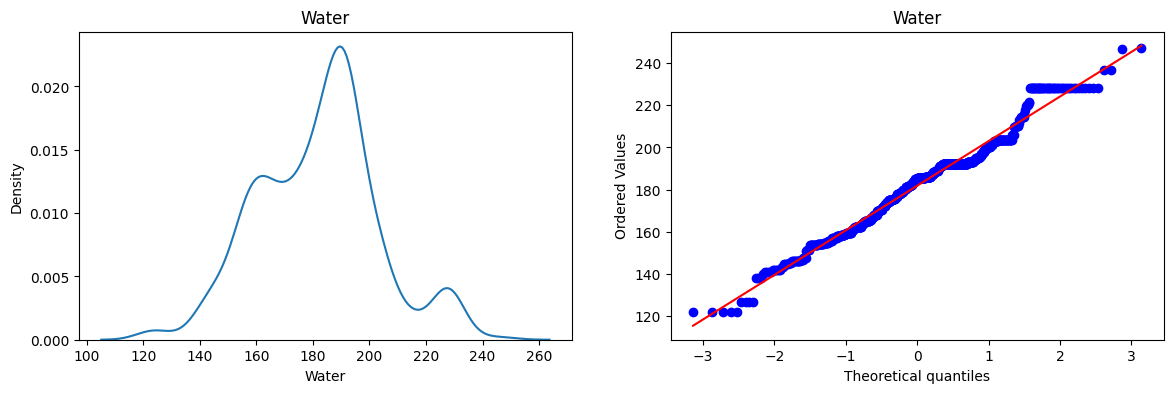

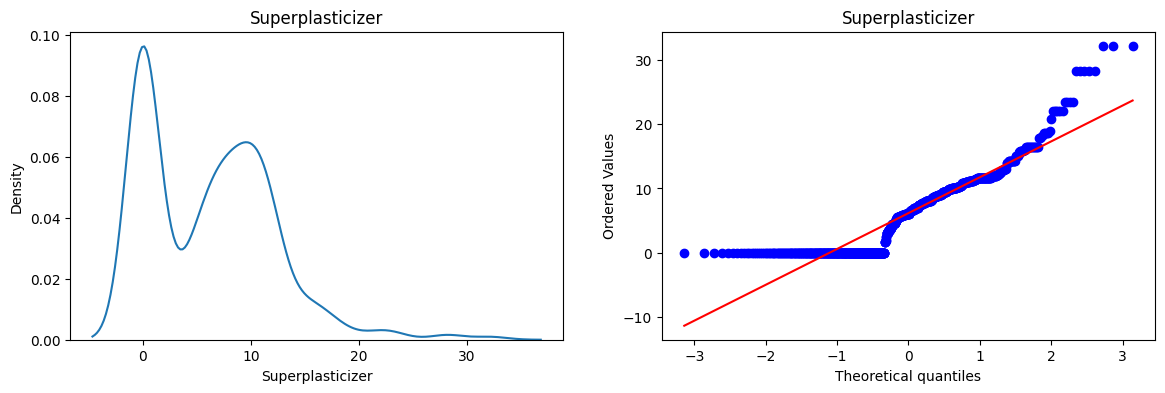

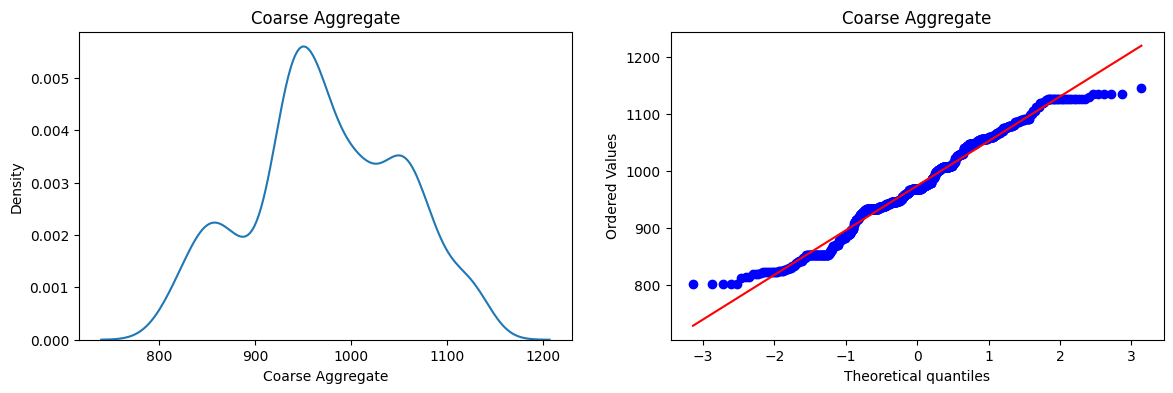

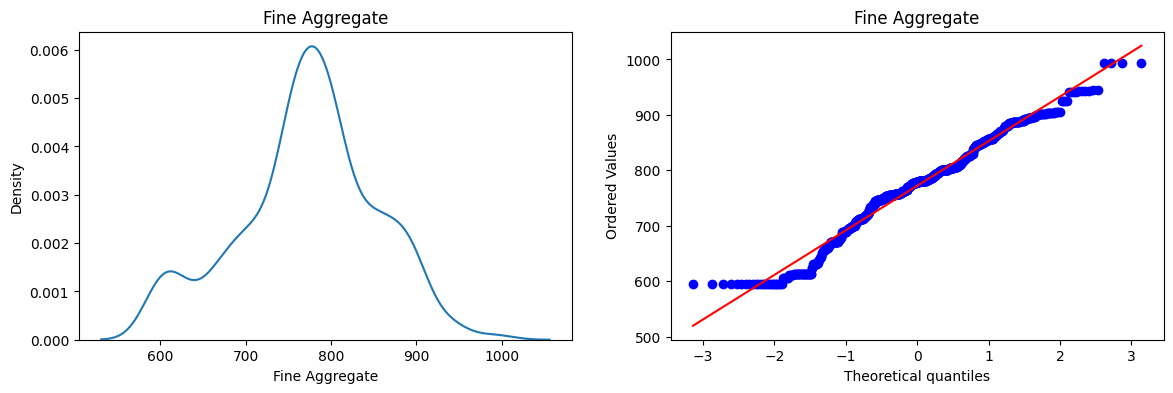

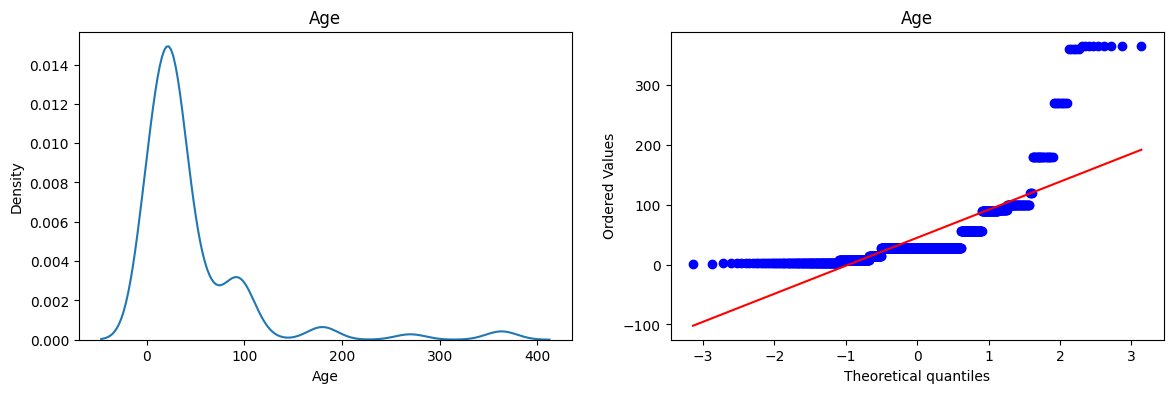

In [48]:
for col in X_train_transformed.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.kdeplot(X_train[col])
  plt.title(col)

  plt.subplot(122)
  probplot(X_train[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()


In [54]:
# Apply Yeo-Johnson transform
pt1 = PowerTransformer()

X_trans_trf1=pt1.fit_transform(X_train+0.0001)
X_test_trf1=pt1.transform(X_test+0.0001)

In [60]:
lr = LinearRegression()
lr.fit(X_trans_trf1,y_train)

y_pred3 = lr.predict(X_test_trf1)
r2_score(y_test,y_pred3)

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,Yeo_Johnson_lambdas
0,Cement,0.169544
1,Blast Furnace Slag,0.016631
2,Fly Ash,-0.136483
3,Water,0.808438
4,Superplasticizer,0.264157
5,Coarse Aggregate,1.129395
6,Fine Aggregate,1.830764
7,Age,0.001767


In [59]:
X_trans_trf2=pt1.fit_transform(X+0.0001)
lr = LinearRegression()
np.mean(cross_val_score(lr,X_trans_trf2,y,scoring='r2'))

np.float64(0.6834632073102617)

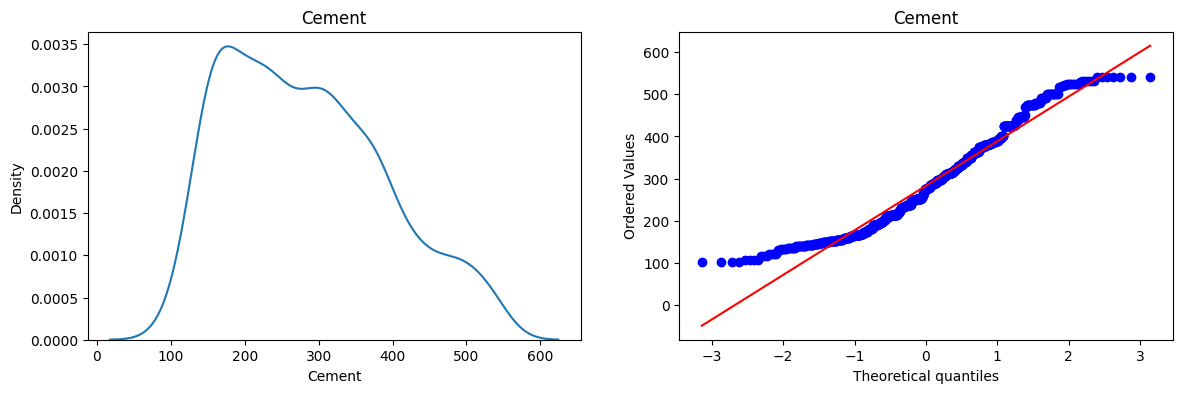

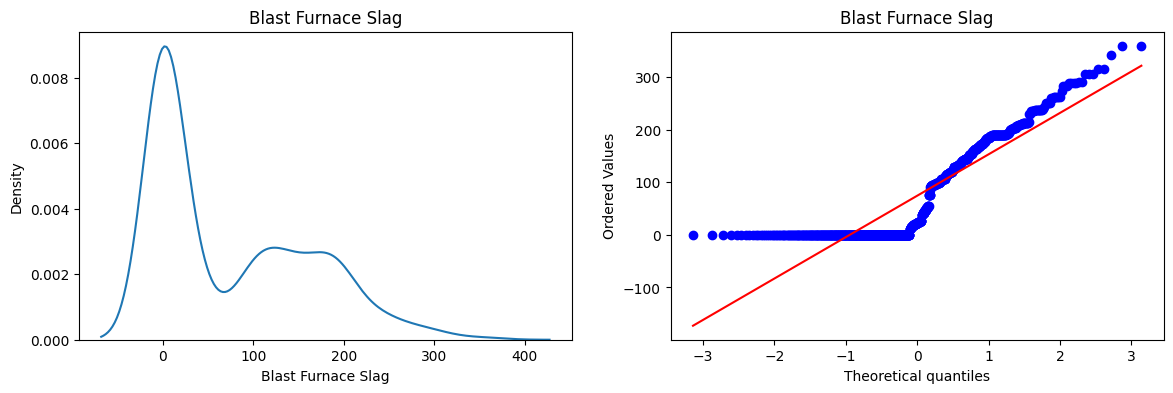

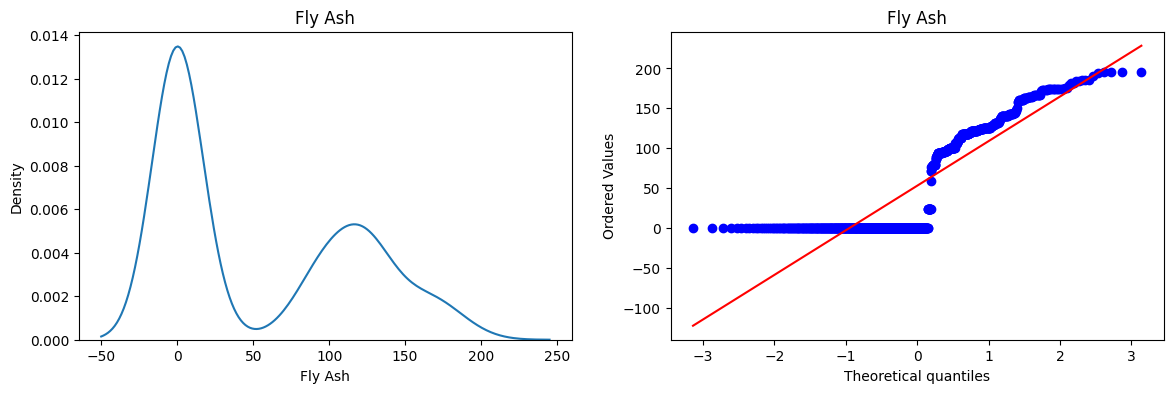

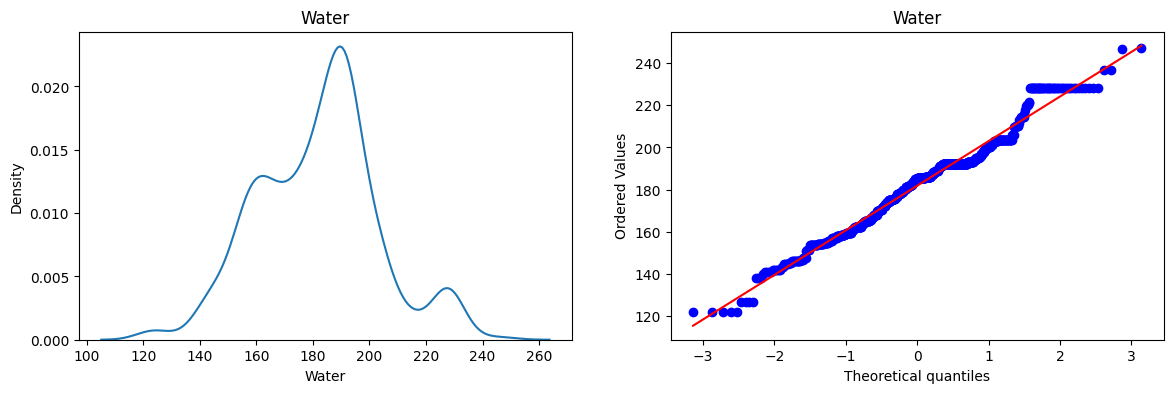

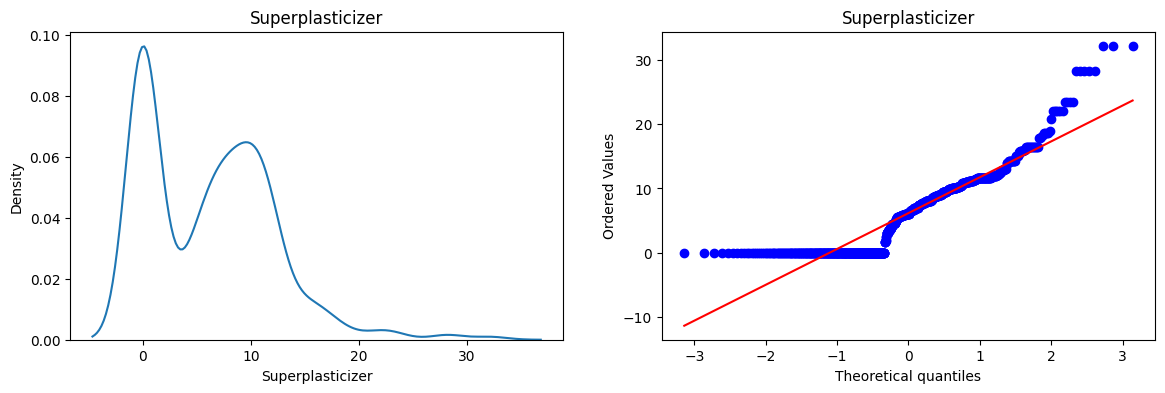

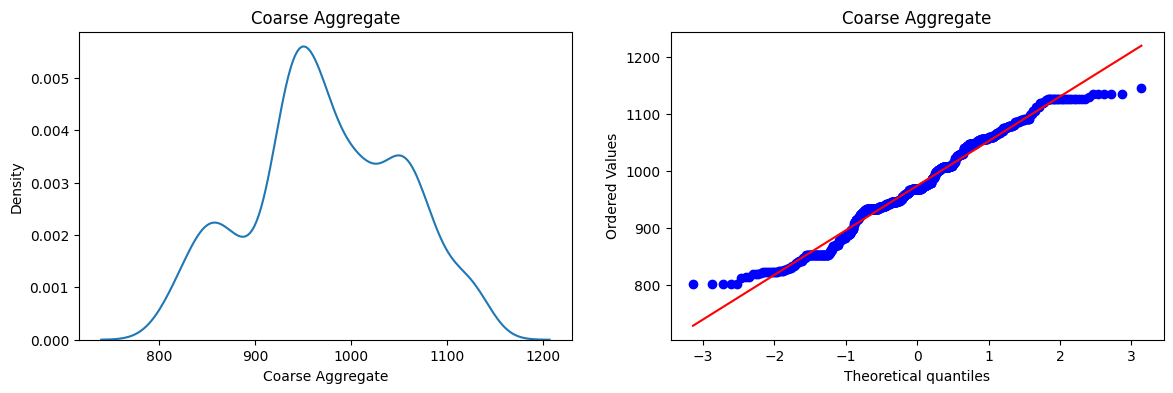

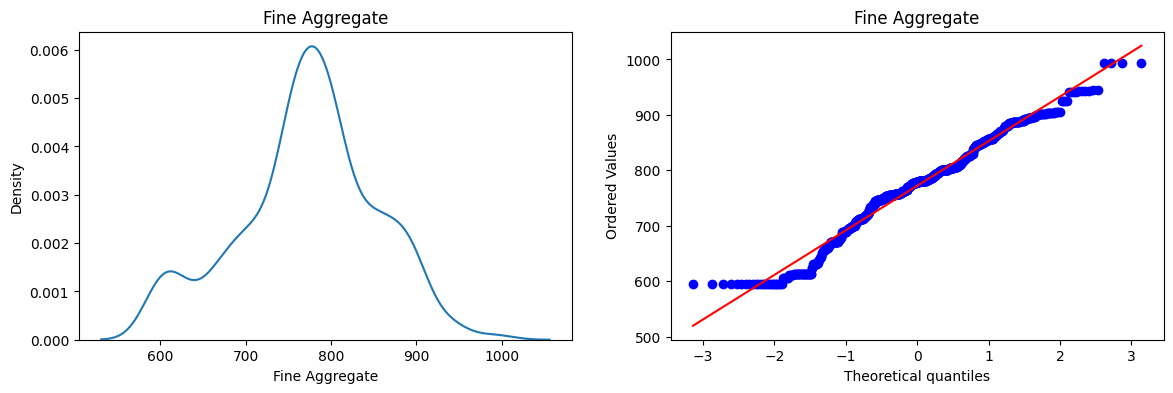

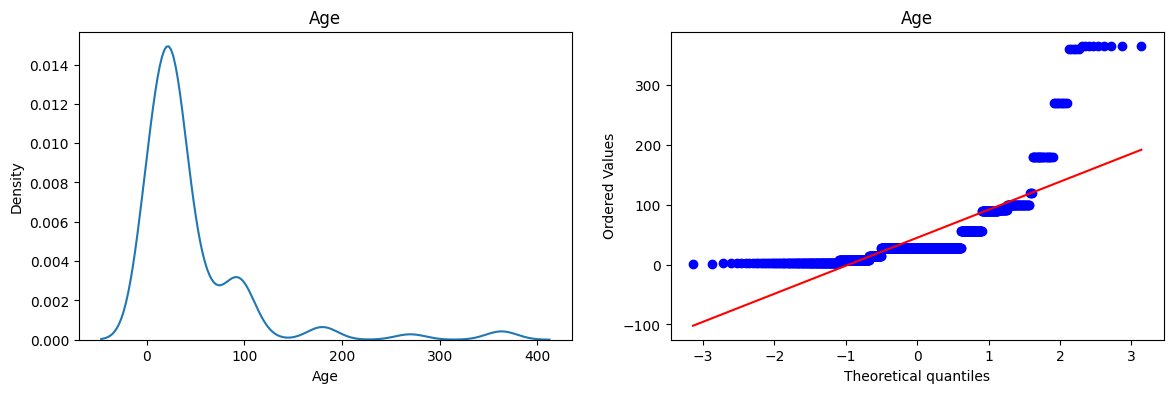

In [58]:
# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_trans_trf2,columns=X_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()


In [62]:
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.172271,0.169544
1,Blast Furnace Slag,0.022924,0.016631
2,Fly Ash,-0.028797,-0.136483
3,Water,0.809568,0.808438
4,Superplasticizer,0.087911,0.264157
5,Coarse Aggregate,1.129167,1.129395
6,Fine Aggregate,1.829625,1.830764
7,Age,0.048975,0.001767
